In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/Ear Diseases/Dataset/Ear diseases and Segmentation.zip" -d /content/ear_seg_dataset

In [ ]:
!ls /content/ear_seg_dataset

test  train  valid


In [ ]:
!ls /content/ear_seg_dataset/train

_annotations.coco.json
aom-100-_jpg.rf.8cf2f9492adac29e930d5f069f6d42d2.jpg
aom-101-_jpg.rf.1c433dfaedc724d6f45a1184fd3d0135.jpg
aom-102-_jpg.rf.d8f0005b1d36b2fd54c2af1974fd6d92.jpg
aom-103-_jpg.rf.139971e70ab0aca3bad3af8894535197.jpg
aom-106-_jpg.rf.c7731b7e90a1741dab5969e488ce7019.jpg
aom-107-_jpg.rf.ab71698aa096b4590bd2cba0ab14aecc.jpg
aom-109-_jpg.rf.8be98aad699b7b995abd0fd4dccc8c98.jpg
aom-110-_jpg.rf.b1c0db2d23baadd4e71e10a50ba0799c.jpg
aom-111-_jpg.rf.1686534ea8831ebe1548f04e59680d52.jpg
aom-114-_jpg.rf.2e659c10e2aef4b49b16e15aeb94263d.jpg
aom-116-_jpg.rf.ed6f71d50695a4d53b72f14bbb0f5b64.jpg
aom-117-_jpg.rf.d0381d2c5b6ef53ee698c5f2cbfe6456.jpg
aom-119-_jpg.rf.1f3a4915281a4705991a12cbf1350af6.jpg
aom-11-_jpg.rf.d750d56962a5777b54bc3aad3af83b27.jpg
aom-120-_jpg.rf.8a196767446800a8efd8395a8680ed05.jpg
aom-122-_jpg.rf.1df95c6758f7e8da9a6339e9ce692d01.jpg
aom-123-_jpg.rf.55011faa94473c1a3edba84296fd7afb.jpg
aom-124-_jpg.rf.bde550c895881a2f7c6856b40faa54e9.jpg
aom-126-_jpg.rf.16a891b2

In [ ]:
import json

annotation_path = "/content/ear_seg_dataset/train/_annotations.coco.json"

with open(annotation_path, "r") as f:
    coco_data = json.load(f)

print("Keys in COCO file:", coco_data.keys())
print("Number of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))
print("Categories:", coco_data["categories"])

Keys in COCO file: dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
Number of images: 2338
Number of annotations: 2341
Categories: [{'id': 0, 'name': 'ear_conditions-zL5Z', 'supercategory': 'none'}, {'id': 1, 'name': 'aom', 'supercategory': 'ear_conditions-zL5Z'}, {'id': 2, 'name': 'ci', 'supercategory': 'ear_conditions-zL5Z'}, {'id': 3, 'name': 'com', 'supercategory': 'ear_conditions-zL5Z'}, {'id': 4, 'name': 'mys', 'supercategory': 'ear_conditions-zL5Z'}, {'id': 5, 'name': 'norm', 'supercategory': 'ear_conditions-zL5Z'}]


In [ ]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

img_info = coco_data["images"][0]
img_id = img_info["id"]
img_file = img_info["file_name"]

img_path = f"/content/ear_seg_dataset/train/{img_file}"

# Load image
image = np.array(Image.open(img_path))

mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

# Find annotations for this image
anns = [ann for ann in coco_data["annotations"] if ann["image_id"] == img_id]

for ann in anns:
    for seg in ann["segmentation"]:
        poly = np.array(seg).reshape((-1,2)).astype(np.int32)
        cv2.fillPoly(mask, [poly], 1)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: (500, 500, 3)
Mask shape: (500, 500)


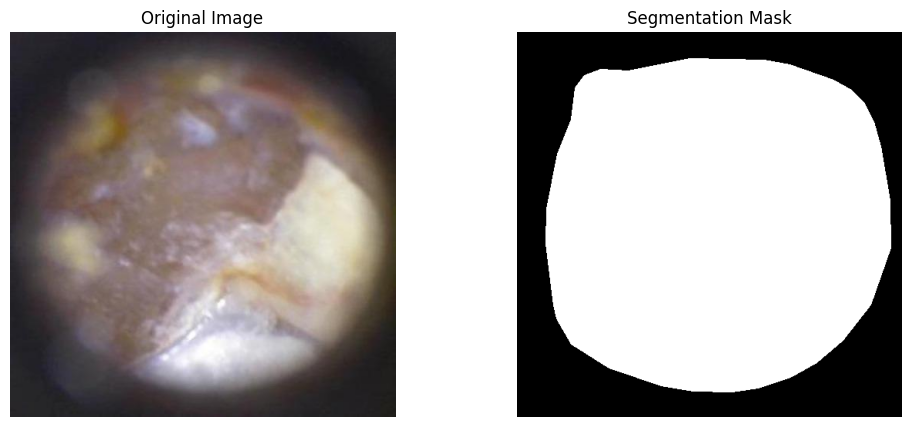

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentation Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
from torch.utils.data import Dataset
import torch

class EarSegDataset(Dataset):
    def __init__(self, coco_data, image_dir, transform=None):
        self.coco = coco_data
        self.image_dir = image_dir
        self.transform = transform
        self.images = coco_data["images"]
        self.annotations = coco_data["annotations"]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info["id"]
        img_file = img_info["file_name"]

        img_path = os.path.join(self.image_dir, img_file)
        image = np.array(Image.open(img_path))

        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        anns = [ann for ann in self.annotations if ann["image_id"] == img_id]

        for ann in anns:
            for seg in ann["segmentation"]:
                poly = np.array(seg).reshape((-1,2)).astype(np.int32)
                cv2.fillPoly(mask, [poly], 1)

        if self.transform:
            image = self.transform(Image.fromarray(image))

        mask = cv2.resize(mask, (224,224))
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [ ]:
from torchvision import transforms

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
import os
dataset = EarSegDataset(
    coco_data,
    "/content/ear_seg_dataset/train",
    transform=val_transforms
)

img, mask = dataset[0]

print("Image tensor shape:", img.shape)
print("Mask tensor shape:", mask.shape)

Image tensor shape: torch.Size([3, 224, 224])
Mask tensor shape: torch.Size([1, 224, 224])


In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        d1 = self.up1(e4)
        d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        out = self.final(d3)

        return torch.sigmoid(out)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/EarProject/models/unet_segmentation.pth"))
model.eval()

print("Segmentation model loaded")

Segmentation model loaded


In [ ]:
# Initialize the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=

In [ ]:
# Creating DataLoaders
from torch.utils.data import DataLoader

train_dataset = EarSegDataset(
    coco_data,
    "/content/ear_seg_dataset/train",
    transform=val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Total training samples:", len(train_dataset))

Total training samples: 2338


In [ ]:
# Loss function and Optimizer
import torch.optim as optim

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/10, Loss: 0.2058
Epoch 2/10, Loss: 0.1519
Epoch 3/10, Loss: 0.1317
Epoch 4/10, Loss: 0.1233
Epoch 5/10, Loss: 0.1174
Epoch 6/10, Loss: 0.1119
Epoch 7/10, Loss: 0.1089
Epoch 8/10, Loss: 0.1086
Epoch 9/10, Loss: 0.1060
Epoch 10/10, Loss: 0.1039


In [ ]:
model = UNet().to(device)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/unet_segmentation.pth",
    map_location=device
))

model.eval()

print("Segmentation model loaded successfully")

Segmentation model loaded successfully


In [ ]:
model.eval()
print("Model set to evaluation mode")

Model set to evaluation mode


In [ ]:
image, mask = dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

Image shape: torch.Size([3, 224, 224])
Mask shape: torch.Size([1, 224, 224])


In [ ]:
import cv2
import numpy as np

def extract_ear_roi(image_tensor, pred_mask):

    img = image_tensor.permute(1,2,0).cpu().numpy()

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    img = (img * 255).astype("uint8")

    mask_uint8 = (pred_mask * 255).astype("uint8")

    kernel = np.ones((5,5), np.uint8)
    mask_uint8 = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img

    largest_contour = max(contours, key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(largest_contour)

    roi = img[y:y+h, x:x+w]
    roi_mask = mask_uint8[y:y+h, x:x+w]

    rgba = np.zeros((roi.shape[0], roi.shape[1], 4), dtype=np.uint8)

    rgba[:, :, :3] = roi
    rgba[:, :, 3] = (roi_mask > 0).astype(np.uint8) * 255

    return rgba

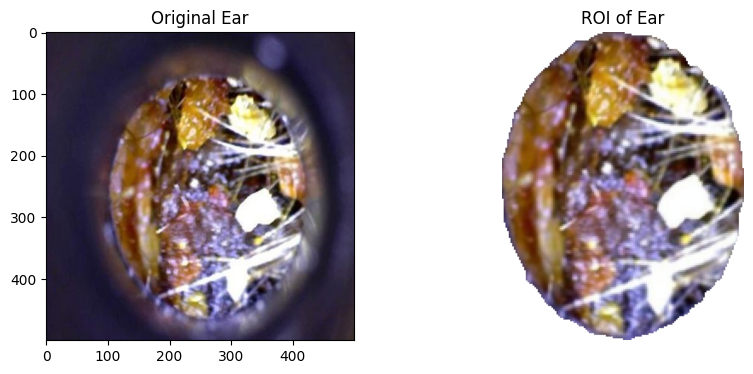

In [ ]:
image_path = "/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/ci-419-_jpg.rf.1823c52f4e6ec18c675abae37402b436.jpg"

image = Image.open(image_path).convert("RGB")

roi, mask = segment_and_crop(image, model, device, val_transforms)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Ear")

plt.subplot(1,2,2)
plt.imshow(roi)
plt.title("ROI of Ear")

plt.axis("off")
plt.show()

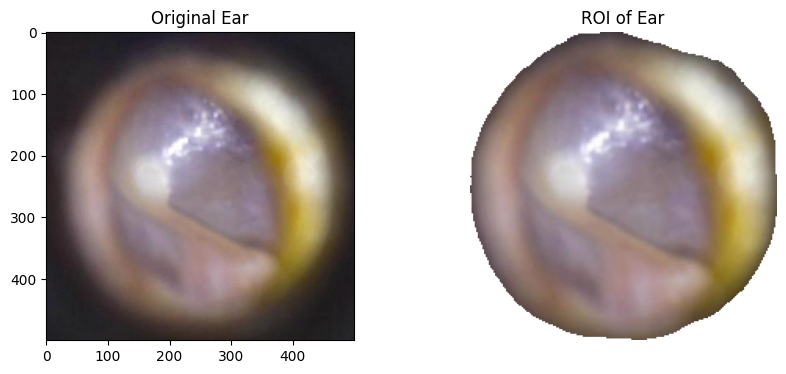

In [ ]:
image_path = "/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/norm-568-_jpg.rf.dec0f94129268761343109aa972e288d.jpg"

image = Image.open(image_path).convert("RGB")

roi, mask = segment_and_crop(image, model, device, val_transforms)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Ear")

plt.subplot(1,2,2)
plt.imshow(roi)
plt.title("ROI of Ear")

plt.axis("off")
plt.show()